# CRI Phase 1: Pillar 1 Comparative Dasymetric Analysis

## Methodology: Empirical vs. Exposure Disaggregation

This notebook implements the **Pillar 1: Human Impact Pipeline** using a comparative dasymetric approach. Outputs are normalized to **Percentiles** (0-100) to ensure consistent color mapping.

---

In [9]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm, BoundaryNorm, ListedColormap
from pathlib import Path

# --- Font Configuration for Thai Characters ---
plt.rcParams['font.family'] = ['Tahoma', 'Inter', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# Paths configuration
base_path = Path('..').resolve().parent
tei_path = base_path / 'data/1_silver/tei_pilot/provincial_casualties_clean.csv'
ddpm_path = base_path / 'data/1_silver/ddpm/tambon_climate_affected_household_aggregate_ddpm_village_stat.csv'
pop_path = base_path / 'data/1_silver/worldpop/tambon_population_count_worldpop.csv'
shp_path = base_path / 'data/1_silver/dopa/tambon_boundaries_enriched.shp'
prov_shp_path = base_path / 'data/1_silver/dopa/province_boundaries_enriched.shp'
gold_out = base_path / 'data/2_gold/human_impact_casualties_by_tambon_comparative.csv'

print(f"Base Workspace: {base_path}")

Base Workspace: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system


In [2]:
# Load datasets
tei_df = pd.read_csv(tei_path, dtype={'province_code': str})
ddpm_df = pd.read_csv(ddpm_path, dtype={'province_code': str, 'subdistrict_code': str})
pop_df = pd.read_csv(pop_path, dtype={'subdist_cd': str, 'prov_code': str})

# Standardize join keys for pop_df
pop_df = pop_df.rename(columns={'subdist_cd': 'subdistrict_code', 'prov_code': 'province_code'})

print("Datasets Loaded Successfully.")

Datasets Loaded Successfully.


In [3]:
# 1. Calculate Weights and Shares
weights = pop_df.merge(ddpm_df, on=['province_code', 'subdistrict_code'], how='outer').fillna(0)
prov_totals = weights.groupby('province_code').agg({'pop_sum': 'sum', 'historical_affected_households_sum': 'sum'}).reset_index()
prov_totals.columns = ['province_code', 'prov_total_pop', 'prov_total_impact']

weights = weights.merge(prov_totals, on='province_code', how='left')
weights['share_pop'] = weights['pop_sum'] / weights['prov_total_pop']
weights['share_impact'] = weights['historical_affected_households_sum'] / weights['prov_total_impact']

# --- Model C: Probability Weight (Synthetic Hybrid) ---
weights['weight_c'] = weights['pop_sum'] * weights['historical_affected_households_sum']
prov_total_c = weights.groupby('province_code')['weight_c'].sum().reset_index().rename(columns={'weight_c': 'prov_total_c'})
weights = weights.merge(prov_total_c, on='province_code', how='left')
weights['share_hybrid'] = weights['weight_c'] / weights['prov_total_c']

weights = weights.fillna(0)
print("Weighting Factors Calculated.")

Weighting Factors Calculated.


In [4]:
# 2. Disaggregate TEI Provincial Totals
tei_prov = tei_df.groupby('province_code').agg({'injured_count_avg_2559_2566': 'sum', 'deaths_count_avg_2559_2566': 'sum'}).reset_index()
tei_prov['total_casualties'] = tei_prov['injured_count_avg_2559_2566'] + tei_prov['deaths_count_avg_2559_2566']
tei_prov['pct_provincial_baseline'] = tei_prov['total_casualties'].rank(pct=True) * 100

analysis = weights.merge(tei_prov, on='province_code', how='inner')
analysis['val_model_a'] = analysis['total_casualties'] * analysis['share_pop']
analysis['val_model_b'] = analysis['total_casualties'] * analysis['share_impact']
analysis['val_model_c'] = analysis['total_casualties'] * analysis['share_hybrid']

# 3. Calculate Percentiles and Rank Shift
analysis['pct_model_a'] = analysis['val_model_a'].rank(pct=True) * 100
analysis['pct_model_b'] = analysis['val_model_b'].rank(pct=True) * 100
analysis['pct_model_c'] = analysis['val_model_c'].rank(pct=True) * 100
analysis['shift_hybrid'] = analysis['pct_model_c'] - analysis['pct_model_a']

analysis.to_csv(gold_out, index=False, encoding='utf-8-sig')
print("Disaggregation and Normalization Complete.")

Disaggregation and Normalization Complete.


## National Visualization: Comparative Models

Compare the raw provincial totals with high-resolution disaggregated models across Thailand.

Loading Geometries...


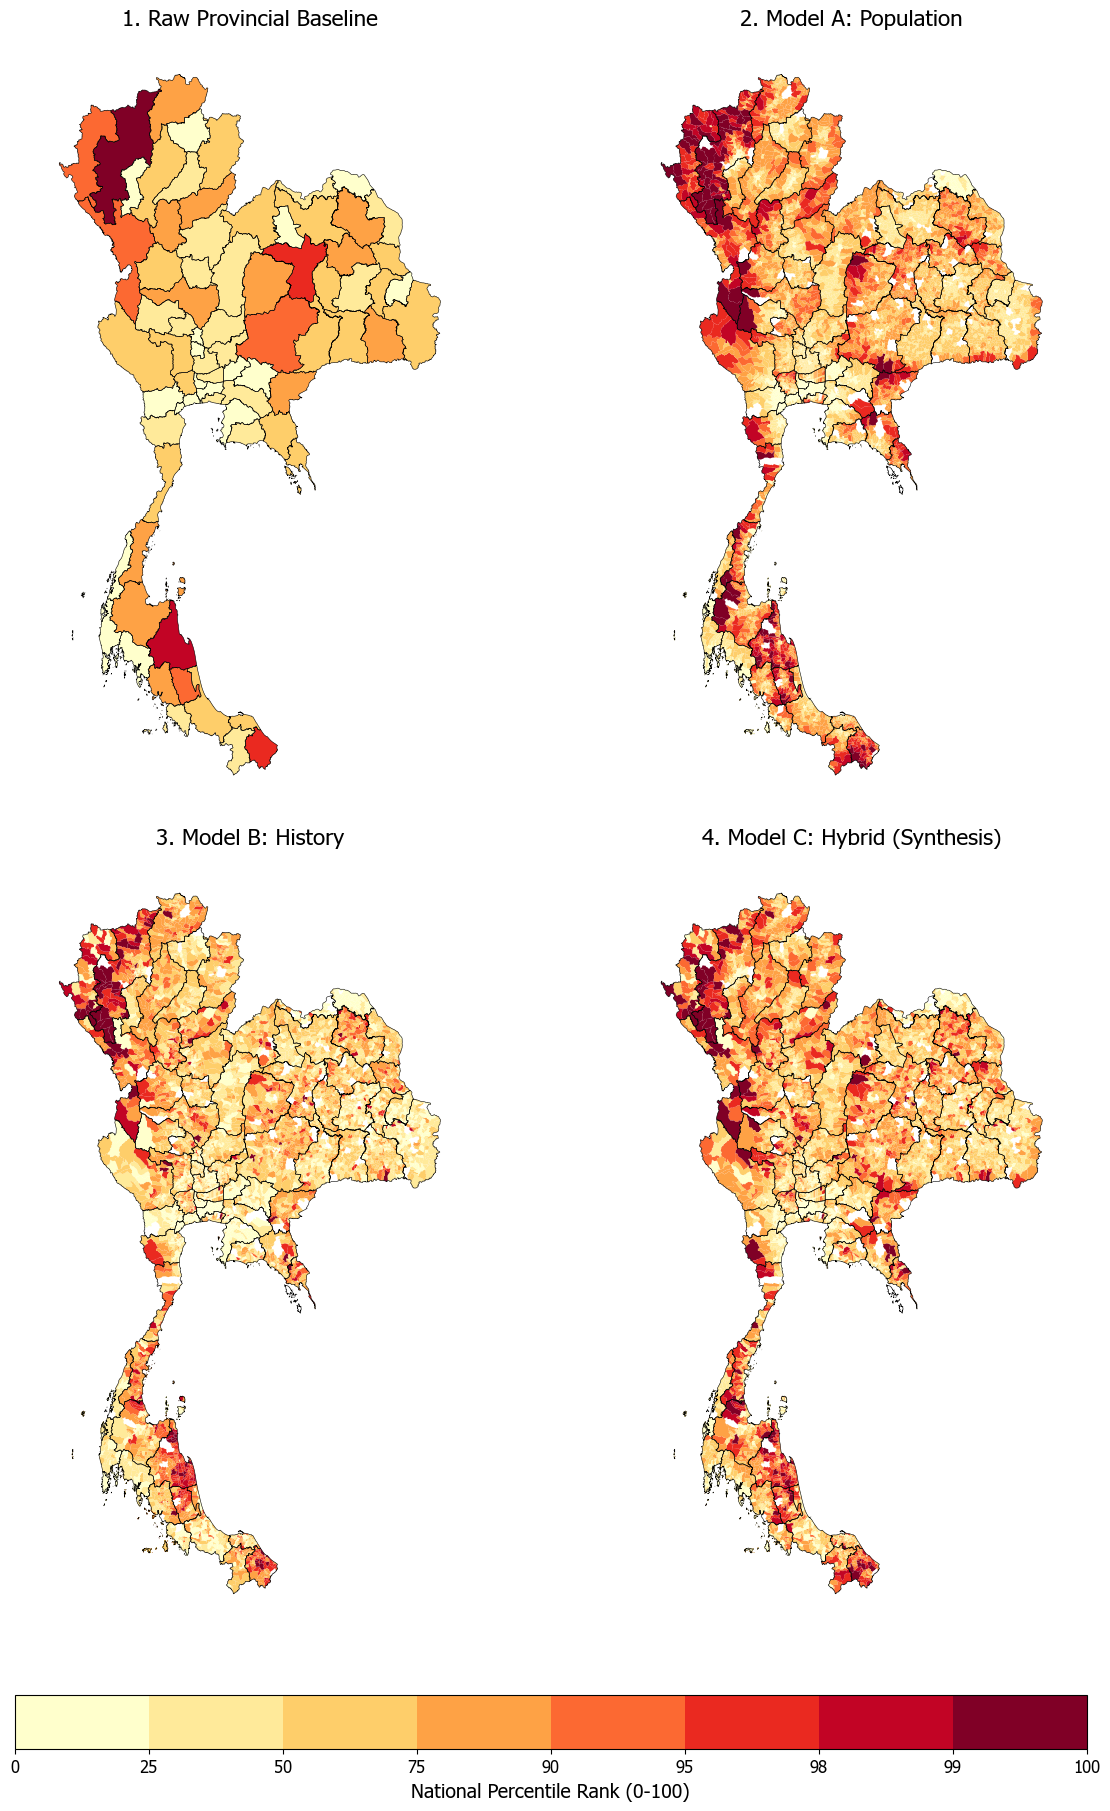

In [19]:
print("Loading Geometries...")
gdf = gpd.read_file(shp_path).rename(columns={'subdist_cd': 'subdistrict_code', 'prov_code': 'province_code'})
prov_gdf = gpd.read_file(prov_shp_path).rename(columns={'prov_code': 'province_code'})
map_df = gdf.merge(analysis, on=['subdistrict_code', 'province_code'], how='inner')
prov_baseline_df = prov_gdf.merge(tei_prov, on='province_code', how='inner')

# Define shared discrete boundaries and colormap
bounds = [0, 25, 50, 75, 90, 95, 98, 99, 100]
cmap = plt.get_cmap('YlOrRd', len(bounds)-1)
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(2, 2, figsize=(12, 18), layout="constrained")
ax = ax.ravel()
# Optional: make titles and labels more readable
title_kwargs = dict(fontsize=16, pad=10)

prov_baseline_df.plot(
    column='pct_provincial_baseline',
    ax=ax[0],
    cmap=cmap,
    norm=norm,
    legend=False
)
prov_gdf.boundary.plot(ax=ax[0], color='black', linewidth=0.4)
ax[0].set_title("1. Raw Provincial Baseline", **title_kwargs)
ax[0].set_axis_off()

map_df.plot(
    column='pct_model_a',
    ax=ax[1],
    cmap=cmap,
    norm=norm,
    legend=False
)
prov_gdf.boundary.plot(ax=ax[1], color='black', linewidth=0.4)
ax[1].set_title("2. Model A: Population", **title_kwargs)
ax[1].set_axis_off()

map_df.plot(
    column='pct_model_b',
    ax=ax[2],
    cmap=cmap,
    norm=norm,
    legend=False
)
prov_gdf.boundary.plot(ax=ax[2], color='black', linewidth=0.4)
ax[2].set_title("3. Model B: History", **title_kwargs)
ax[2].set_axis_off()

map_df.plot(
    column='pct_model_c',
    ax=ax[3],
    cmap=cmap,
    norm=norm,
    legend=False
)
prov_gdf.boundary.plot(ax=ax[3], color='black', linewidth=0.4)
ax[3].set_title("4. Model C: Hybrid (Synthesis)", **title_kwargs)
ax[3].set_axis_off()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation='horizontal',
    fraction=0.04,
    pad=0.04,
    shrink=0.9
)
cbar.set_label('National Percentile Rank (0-100)', fontsize=14)
cbar.ax.tick_params(labelsize=12)

## 6. Regional Deep-Dive: Side-by-Side Comparison

Examine specific provinces to see the granular shift in risk hotspots including the Hybrid model.

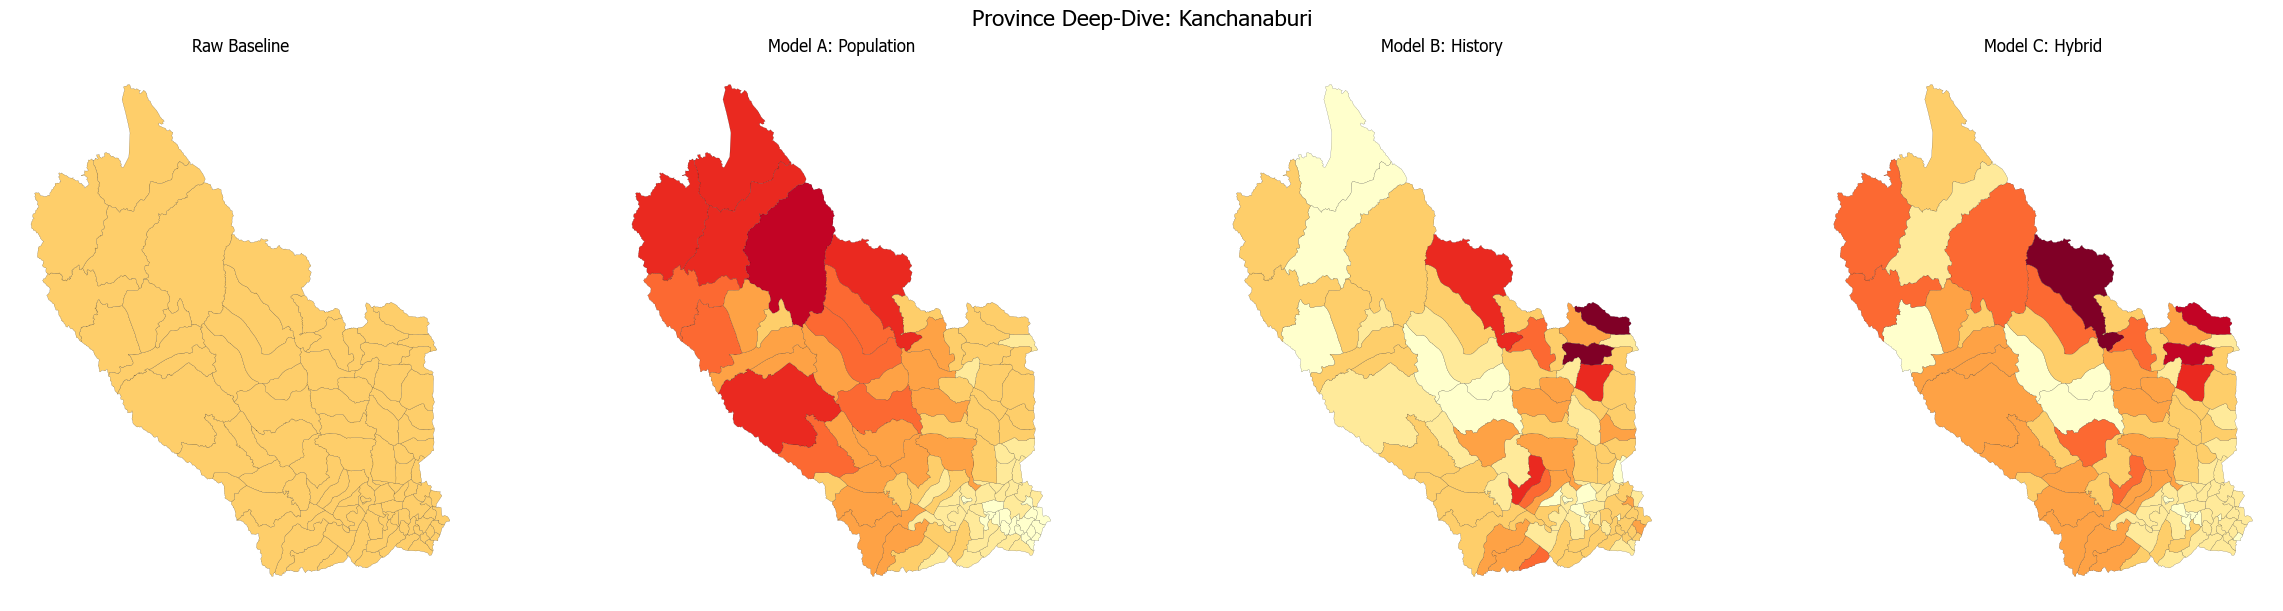

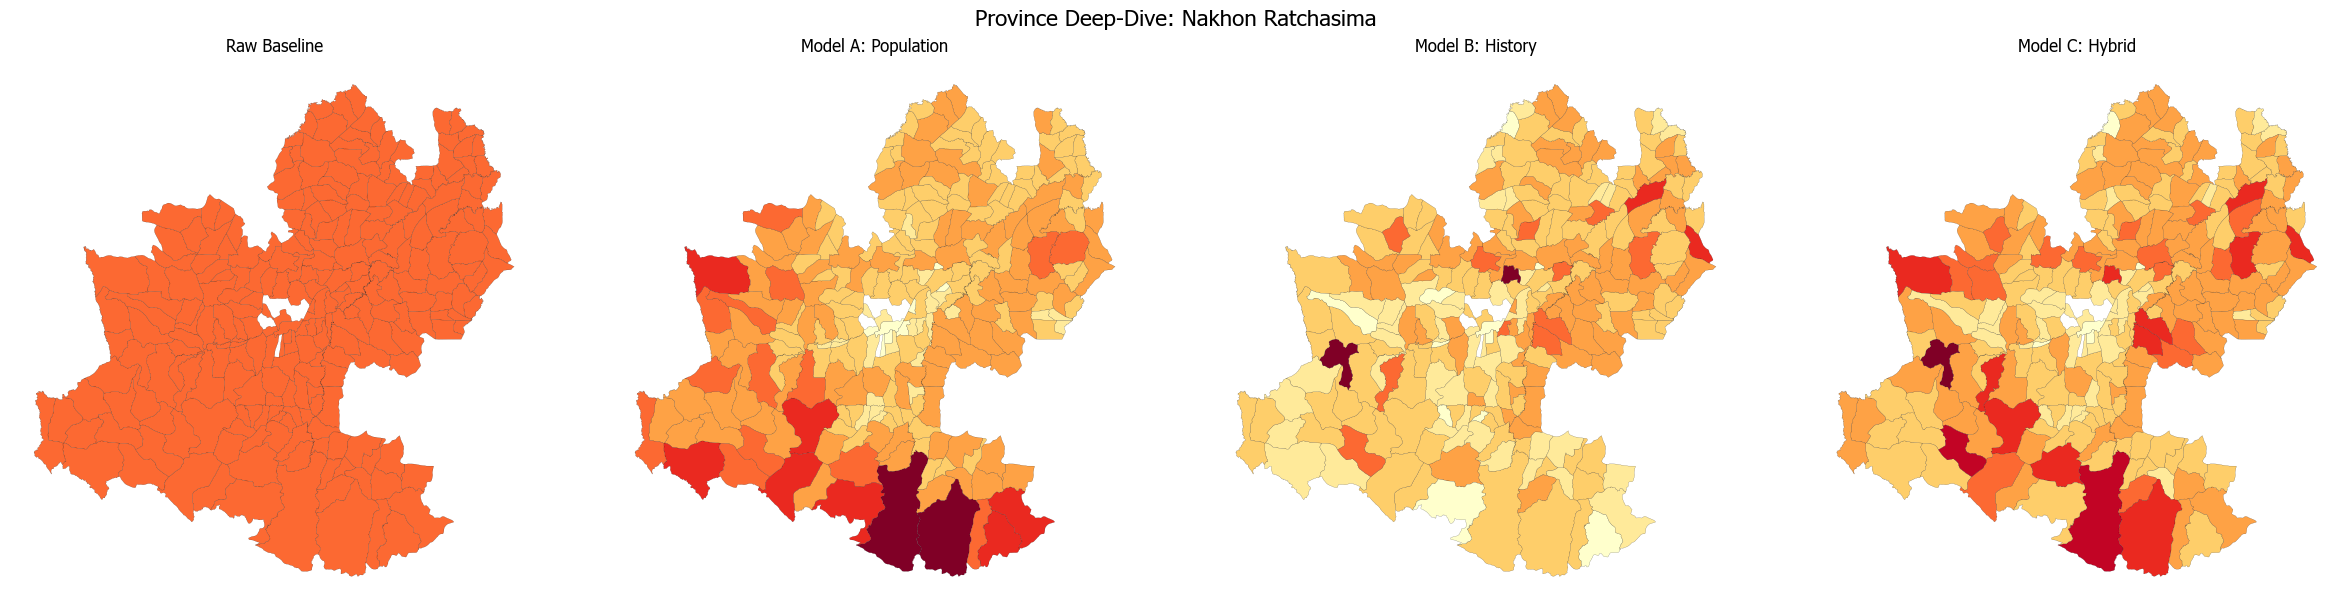

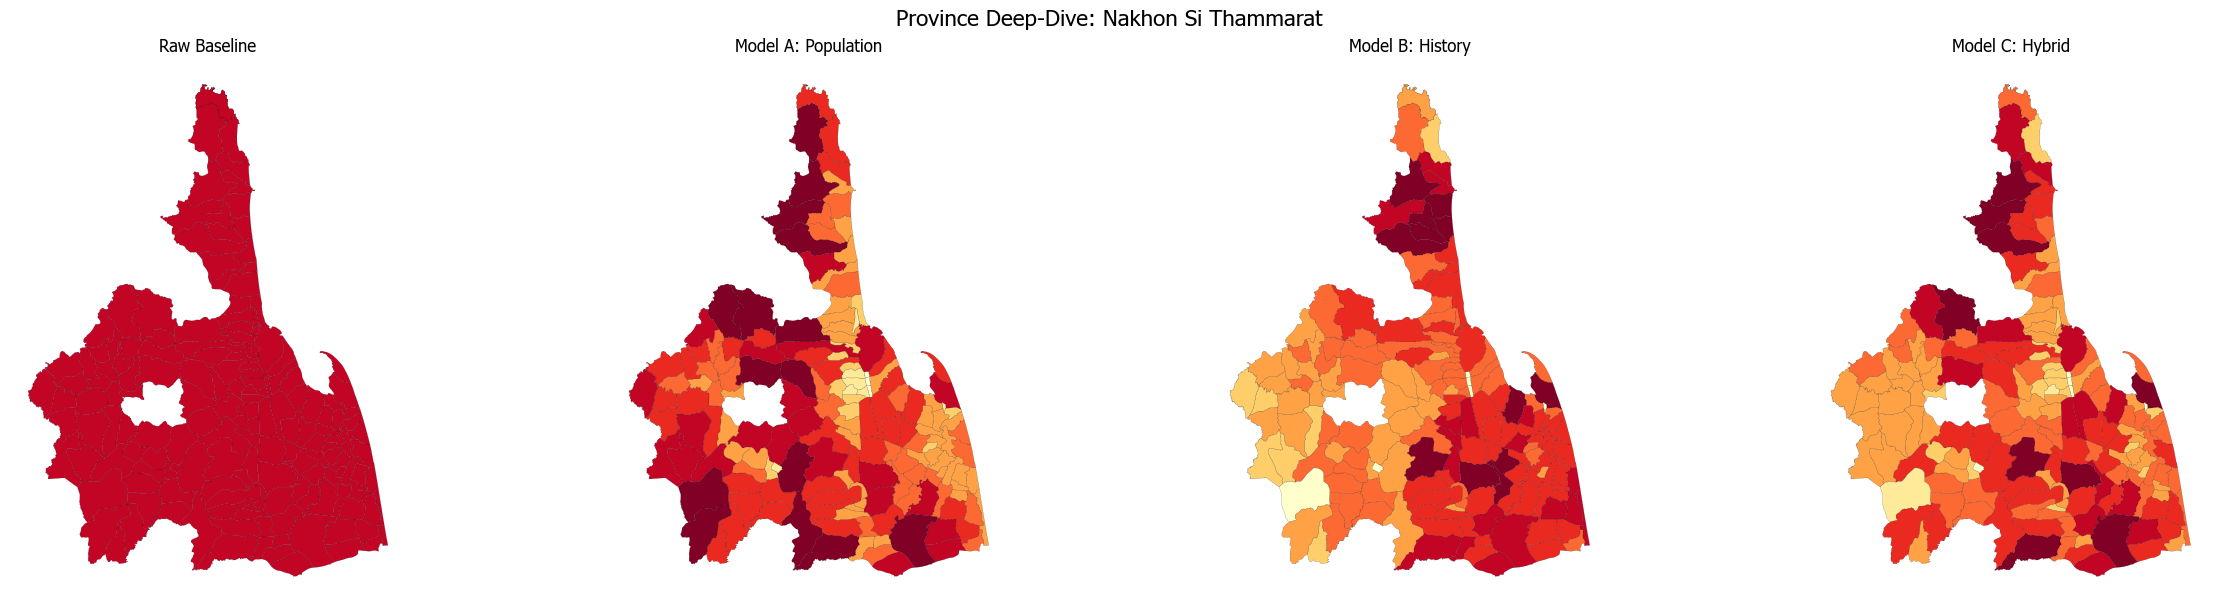

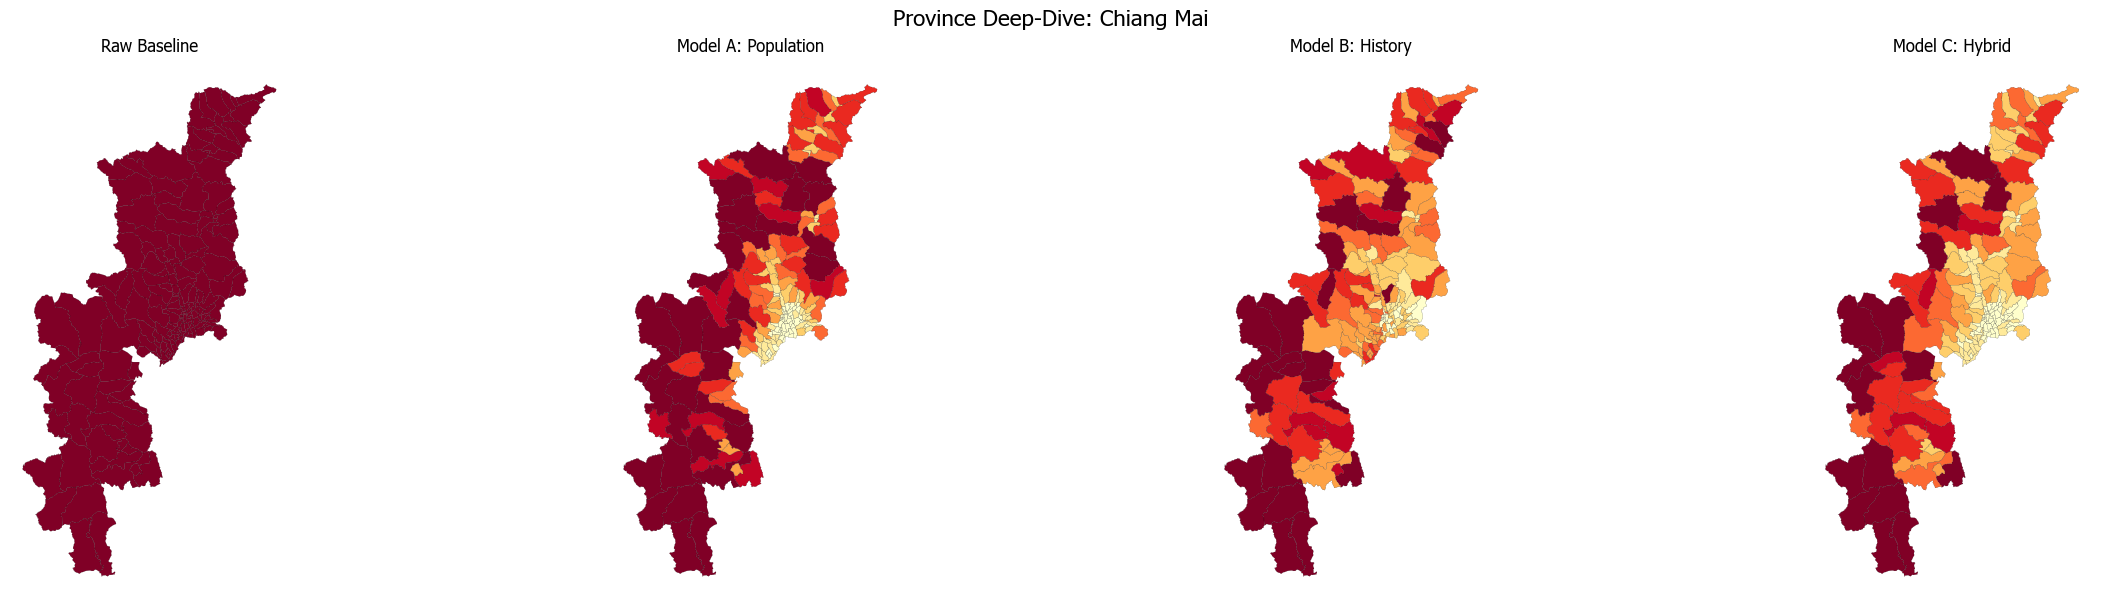

In [21]:
target_provinces = {'71': 'Kanchanaburi', '30': 'Nakhon Ratchasima', '80': 'Nakhon Si Thammarat', '50': 'Chiang Mai'}

for p_code, p_name in target_provinces.items():
    prov_subset = map_df[map_df['province_code'] == p_code]
    if prov_subset.empty: continue
    
    fig, ax = plt.subplots(1, 4, figsize=(24, 6), layout="constrained")
    fig.suptitle(f"Province Deep-Dive: {p_name}", fontsize=16)
    
    # Baseline color from provincial data
    prov_subset.plot(column='pct_provincial_baseline', ax=ax[0], cmap=cmap, norm=norm, edgecolor='black', linewidth=0.1)
    ax[0].set_title("Raw Baseline")
    
    prov_subset.plot(column='pct_model_a', ax=ax[1], cmap=cmap, norm=norm, edgecolor='black', linewidth=0.1)
    ax[1].set_title("Model A: Population")
    
    prov_subset.plot(column='pct_model_b', ax=ax[2], cmap=cmap, norm=norm, edgecolor='black', linewidth=0.1)
    ax[2].set_title("Model B: History")
    
    prov_subset.plot(column='pct_model_c', ax=ax[3], cmap=cmap, norm=norm, edgecolor='black', linewidth=0.1)
    ax[3].set_title("Model C: Hybrid")
    
    for a in ax: a.axis('off')
    plt.show()

## 7. Provincial Anomaly Analysis

Aggregation of the Hybrid shift identifying provinces where synthesis most significantly alters the population-only view.

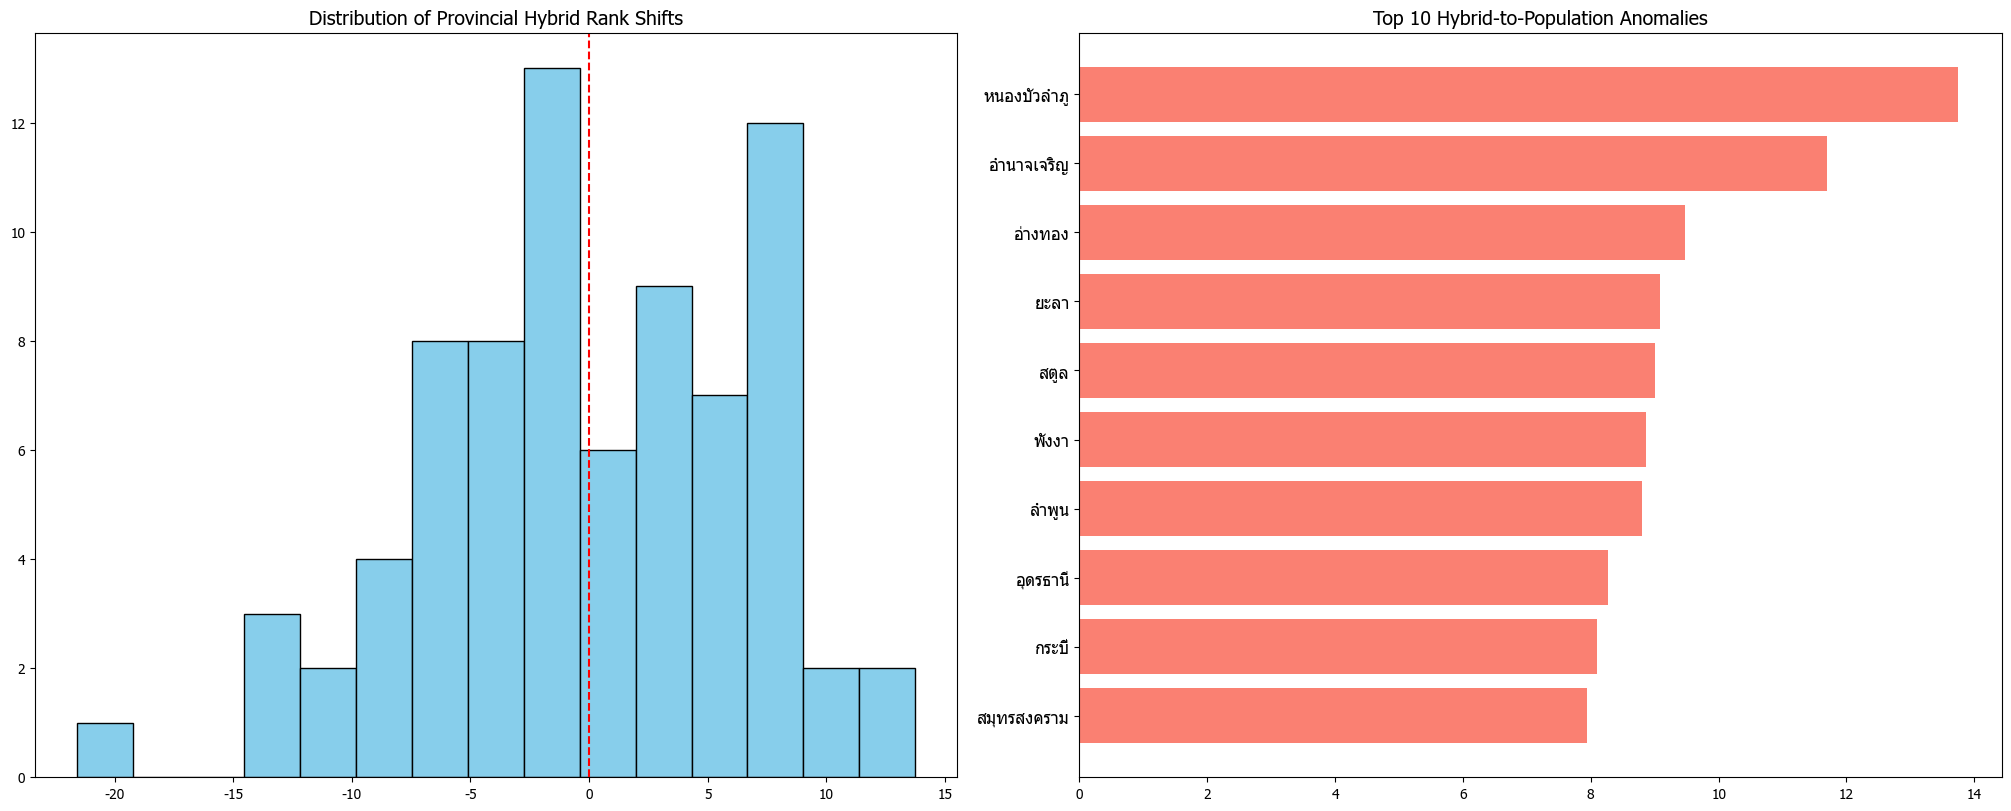

In [22]:
name_map = tei_df[['province_code', 'province_name_th']].drop_duplicates()
prov_anomaly = analysis.groupby('province_code')['shift_hybrid'].mean().reset_index()
prov_anomaly = prov_anomaly.merge(name_map, on='province_code', how='left').sort_values('shift_hybrid', ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(20, 8), layout="constrained")
ax[0].hist(prov_anomaly['shift_hybrid'], bins=15, color='skyblue', edgecolor='black')
ax[0].axvline(0, color='red', linestyle='--')
ax[0].set_title("Distribution of Provincial Hybrid Rank Shifts", fontsize=14)

top_10 = prov_anomaly.head(10)
ax[1].barh(top_10['province_name_th'], top_10['shift_hybrid'], color='salmon')
ax[1].invert_yaxis() 
ax[1].set_title("Top 10 Hybrid-to-Population Anomalies", fontsize=14)
ax[1].tick_params(axis='y', labelsize=12)
plt.show()

## 8. National Risk Anomaly (Rank Shift Map)

National delta identifying areas where history predicts higher risk than simple exposure.

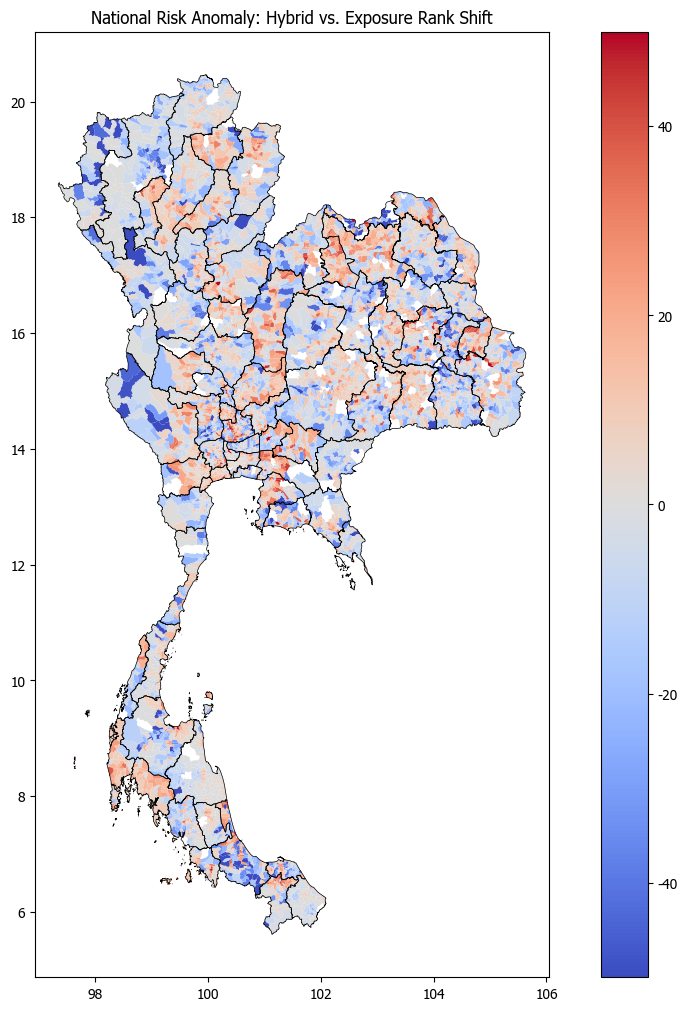

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), layout="constrained")
map_df.plot(column='shift_hybrid', ax=ax, cmap='coolwarm', legend=True, vmin=-50, vmax=50)
prov_gdf.boundary.plot(ax=ax, color='black', linewidth=0.5)
ax.set_title("National Risk Anomaly: Hybrid vs. Exposure Rank Shift")
plt.show()